In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rc
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib import colors
from cycler import cycler

# ======================================================
# === Font and size controls (adjust freely) ===
# ======================================================
font_family = 'Arial'
font_title = 22
font_labels = 24
font_ticks = 21
font_legend = 16
font_general = 14
# ======================================================

# === Global rc settings ===
rc('font', family=font_family, size=font_general)
plt.rcParams['axes.titlesize'] = font_title
rc('axes', labelsize=font_labels)
rc('xtick', labelsize=font_ticks)
rc('ytick', labelsize=font_ticks)
rc('legend', fontsize=font_legend)
rc('axes.spines', **{'right': True, 'top': True})

plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

#Set custom colors
custom_colors = [
    "#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F",
    "#8491B4", "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
]

plt.rcParams['axes.prop_cycle'] = cycler(color=custom_colors)
sns.set_palette(custom_colors)

In [ ]:
import numpy as np
import pandas as pd
import json
import os
import glob
from typing import Dict, List
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math
import sys
import os
from scipy.stats import gaussian_kde
sys.path.append('retry')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rc
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from math import comb
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d

In [11]:
# constants
R = 8.314462618  # kg*m^2*s^-2*mol^-1*K^-1
T = 298.15  # K
F = 96485.33212  # A*s*mol^-1
scan_rate = 1
kc = 1

logl_min, logl_max = -3, 4
logg_min, logg_max = -3, 3
n = 25

# build centered log grids
log_l_vals, ret_step = np.linspace(logl_min, logl_max, n, endpoint=False, retstep=True)
log_l_vals += ret_step / 2

log_g_vals, ret_step = np.linspace(logg_min, logg_max, n, endpoint=False, retstep=True)
log_g_vals += ret_step / 2

LOGL, LOGG = np.meshgrid(log_l_vals, log_g_vals)

# convert from log space
lam = 10**LOGL   # l
g = 10**LOGG     # g

# compute concentrations
ccat_grid = lam * scan_rate * F / (R * T * kc)
csub_grid = g * ccat_grid

# flatten for storage
ccat_values = ccat_grid.flatten()
csub_values = csub_grid.flatten()

In [12]:
ccat_grid

array([[5.37269637e-02, 1.02374619e-01, 1.95070815e-01, 3.71699774e-01,
        7.08259319e-01, 1.34956031e+00, 2.57153416e+00, 4.89995732e+00,
        9.33667620e+00, 1.77906697e+01, 3.38994223e+01, 6.45940176e+01,
        1.23081363e+02, 2.34526703e+02, 4.46881419e+02, 8.51514989e+02,
        1.62252836e+03, 3.09166406e+03, 5.89104442e+03, 1.12251537e+04,
        2.13890895e+04, 4.07560698e+04, 7.76590900e+04, 1.47976345e+05,
        2.81963113e+05],
       [5.37269637e-02, 1.02374619e-01, 1.95070815e-01, 3.71699774e-01,
        7.08259319e-01, 1.34956031e+00, 2.57153416e+00, 4.89995732e+00,
        9.33667620e+00, 1.77906697e+01, 3.38994223e+01, 6.45940176e+01,
        1.23081363e+02, 2.34526703e+02, 4.46881419e+02, 8.51514989e+02,
        1.62252836e+03, 3.09166406e+03, 5.89104442e+03, 1.12251537e+04,
        2.13890895e+04, 4.07560698e+04, 7.76590900e+04, 1.47976345e+05,
        2.81963113e+05],
       [5.37269637e-02, 1.02374619e-01, 1.95070815e-01, 3.71699774e-01,
        7.0825

In [13]:
csub_grid

array([[7.08259319e-05, 1.34956031e-04, 2.57153416e-04, 4.89995732e-04,
        9.33667620e-04, 1.77906697e-03, 3.38994223e-03, 6.45940176e-03,
        1.23081363e-02, 2.34526703e-02, 4.46881419e-02, 8.51514989e-02,
        1.62252836e-01, 3.09166406e-01, 5.89104442e-01, 1.12251537e+00,
        2.13890895e+00, 4.07560698e+00, 7.76590900e+00, 1.47976345e+01,
        2.81963113e+01, 5.37269637e+01, 1.02374619e+02, 1.95070815e+02,
        3.71699774e+02],
       [1.23081363e-04, 2.34526703e-04, 4.46881419e-04, 8.51514989e-04,
        1.62252836e-03, 3.09166406e-03, 5.89104442e-03, 1.12251537e-02,
        2.13890895e-02, 4.07560698e-02, 7.76590900e-02, 1.47976345e-01,
        2.81963113e-01, 5.37269637e-01, 1.02374619e+00, 1.95070815e+00,
        3.71699774e+00, 7.08259319e+00, 1.34956031e+01, 2.57153416e+01,
        4.89995732e+01, 9.33667620e+01, 1.77906697e+02, 3.38994223e+02,
        6.45940176e+02],
       [2.13890895e-04, 4.07560698e-04, 7.76590900e-04, 1.47976345e-03,
        2.8196

In [14]:
logl_comp = np.log10((R*T/F)*(kc*ccat_values/scan_rate))
logg_comp = np.log10(csub_values/ccat_values)

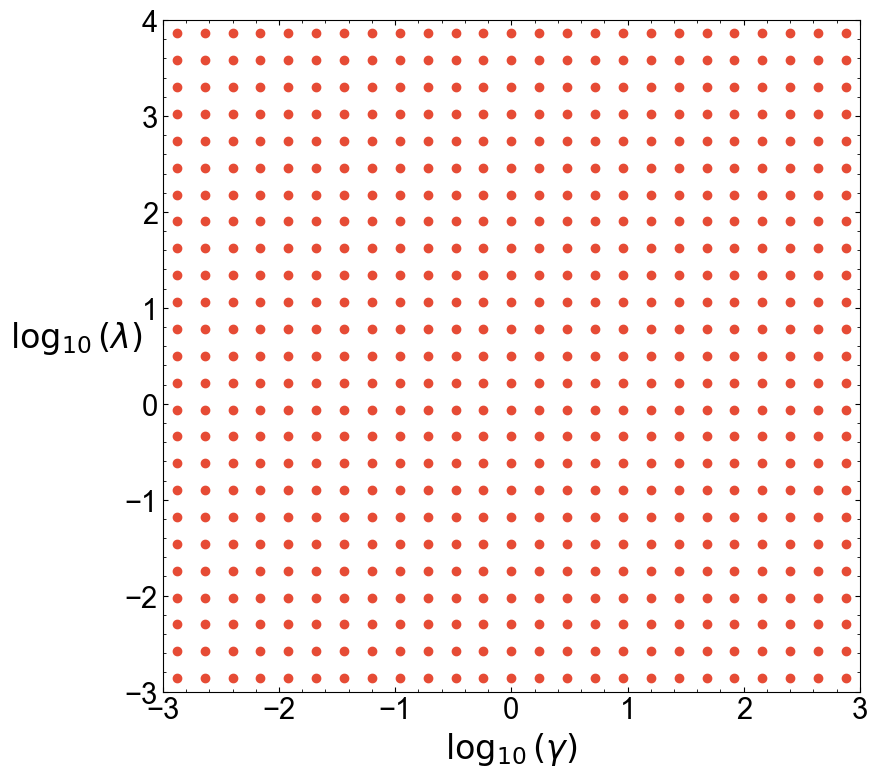

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(logg_comp, logl_comp)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 4)

ax.set_xlabel(r"$\log_{10}(\gamma)$")
ax.set_ylabel(r"$\log_{10}(\lambda)$", rotation=0, labelpad=35)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.minorticks_on()

plt.tight_layout()
plt.savefig("points_for_zones_ecprime.png", dpi=300)
plt.show()

In [16]:
# Target point
target_logg = 0
target_logl = 4

# Compute Euclidean distance to (0, 4)
distances = np.sqrt((logg_comp - target_logg)**2 + (logl_comp - target_logl)**2)

# Find index of closest point
idx_closest = np.argmin(distances)

# Extract corresponding values
closest_ccat = ccat_values[idx_closest]
closest_csub = csub_values[idx_closest]

print("Closest index:", idx_closest)
print("ccat_value:", closest_ccat)
print("csub_value:", closest_csub)

Closest index: 324
ccat_value: 281963.113414701
csub_value: 281963.11341470096


In [32]:
import numpy as np
import plotly.express as px
import plotly.io as pio
import pandas as pd
pio.renderers.default = "browser"

# constants
R = 8.314462618
T = 298.15
F = 96485.33212
scan_rate = 1
kc = 1

logl_min, logl_max = -3, 4
logg_min, logg_max = -3, 3
n = 25

# build centered log grids
log_l_vals, ret_step = np.linspace(logl_min, logl_max, n, endpoint=False, retstep=True)
log_l_vals += ret_step / 2

log_g_vals, ret_step = np.linspace(logg_min, logg_max, n, endpoint=False, retstep=True)
log_g_vals += ret_step / 2

LOGL, LOGG = np.meshgrid(log_l_vals, log_g_vals)

# convert from log space
lam = 10**LOGL
g = 10**LOGG

# compute concentrations
ccat_grid = lam * scan_rate * F / (R * T * kc)
csub_grid = g * ccat_grid

# flatten for storage
ccat_values = ccat_grid.flatten()
csub_values = csub_grid.flatten()

logl_comp = np.log10((R*T/F)*(kc*ccat_values/scan_rate))
logg_comp = np.log10(csub_values/ccat_values)

# build dataframe for Plotly
df = pd.DataFrame({
    "log_gamma": logg_comp,
    "log_lambda": logl_comp,
    "ccat": ccat_values,
    "csub": csub_values
})

# interactive plot
fig = px.scatter(
    df,
    x="log_gamma",
    y="log_lambda",
    hover_data={
        "ccat": True,
        "csub": True,
        "log_gamma": False,
        "log_lambda": False
    }
)

fig.update_layout(
    xaxis_title=r"log10(γ)",
    yaxis_title=r"log10(λ)",
    width=900,
    height=800
)

fig.show()

In [18]:
comsol_params = {
    'startPotential': -1.0,
    'numCycles': 1,
    'vertexPotential1': 1.0,
    'vertexPotential2': -1.0,
    'endPotential': -1.0,
    'electrodeRadius': 1.0,  # mm
    'startScanRate': 0.0001,  # V/s
    'endScanRate': 100000.0,  # V/s  
    'scanRateCount': 5,
    'normalizeCurrent': True,
}

# Get the direction of the scan
start_potential = comsol_params.get('startPotential', -1.0)
num_cycles = int(comsol_params.get('numCycles', 1)) - 1    # Subtract 1 to make the results more logical
vertex_potential_1 = comsol_params.get('vertexPotential1', 1.0)
vertex_potential_2 = comsol_params.get('vertexPotential2', -1.0)
end_potential = comsol_params.get('endPotential', -1.0)

In [19]:
def compute_mse_t(t_ref, I_ref, t_cmp, I_cmp):
    """
    Interpolate I_cmp onto t_ref and compute MSE.
    Restricts to the overlapping time window.
    """
    t_min = max(t_ref.min(), t_cmp.min())
    t_max = min(t_ref.max(), t_cmp.max())

    # restrict to overlap
    mask_ref = (t_ref >= t_min) & (t_ref <= t_max)
    t_ref_clip = t_ref[mask_ref]
    I_ref_clip = I_ref[mask_ref]

    # interpolate comparator current
    I_cmp_interp = np.interp(t_ref_clip, t_cmp, I_cmp)

    return mean_squared_error(I_ref_clip, I_cmp_interp)

def potential_to_time(potential, scan_rate):
    potential = np.asarray(potential)
    dE = np.abs(np.diff(potential))      # potential differences
    dt = dE / scan_rate                  # time increments
    time = np.concatenate(([0], np.cumsum(dt)))
    return time

def find_culprit(key):
    """Find which model is the culprit in disagreement"""
    possible_models = ["ecsim", "DigiSim", "COMSOL"]
    for model in possible_models:
        if model not in key.split():
            return model
    return None

def check_disagreement(row):
    """
    Check if any model particularly disagrees with the others.
    Disagreement means one entry has more or less than 50 times 
    the mean of the other two entries in the row.
    Returns (disagreement: bool, culprit: str)
    """
    values = list(row.values())
    keys = list(row.keys())
    
    # Check each value to see if it disagrees with the mean of the other two
    for i, (key, value) in enumerate(zip(keys, values)):
        other_values = [v for j, v in enumerate(values) if j != i]
        mean_others = np.mean(other_values)
        
        # Avoid division by zero
        if mean_others == 0:
            if value != 0:
                return True, find_culprit(key)
            continue
            
        ratio = value / mean_others
        if ratio > 50 or ratio < 1/50:
            return True, find_culprit(key)
    
    return False, None

In [20]:
def extract_parameters_from_json(json_file):
    """Extract parameters dynamically from JSON file"""
    with open(json_file, 'r') as f:
        params = json.load(f)
    
    extracted = {}
    
    # Extract parameters for each step dynamically
    for step_name, step_data in params.items():
        step_type = step_data['type']
        step_params = step_data['params']
        
        if step_type == 'E':
            # Electrochemical step: n, type, E0, k0, alpha
            extracted[f'{step_name}_n'] = step_params[0]
            extracted[f'{step_name}_type'] = step_params[1]
            extracted[f'{step_name}_E0'] = step_params[2]
            extracted[f'{step_name}_k0'] = step_params[3]
            extracted[f'{step_name}_alpha'] = step_params[4]
        elif step_type == 'C':
            # Chemical step: kf, kb
            extracted[f'{step_name}_kf'] = step_params[0]
            extracted[f'{step_name}_kb'] = step_params[1]
            
    extracted['csub'] = params['S1']['params']
    extracted['ccat'] = params['I1']['params']
    
    return extracted

def process_all_simulations(base_dir="."):
    """Process all simulation files and compute MSE metrics.
    Returns a dictionary mapping mechanism names to DataFrames."""
    
    scan_rates = np.logspace(0, 0, 1)
    mechanism_dataframes = {}  # Dictionary to store DataFrames per mechanism
    
    mechanism_dirs = sorted(
        d for d in glob.glob(os.path.join(base_dir, "EC_prime_new"))
        if os.path.isdir(d)
    )
    
    for mechanism_dir in mechanism_dirs:
        mechanism_name = os.path.basename(mechanism_dir)
        print(f"Processing mechanism {mechanism_name}")
        mechanism_results = []  # Results for this specific mechanism
        
        model_dirs = sorted(glob.glob(os.path.join(mechanism_dir, "model_*")))
        
        for model_dir in model_dirs:
            model_results = []  # Temporary storage for this model
            
            try:
                model_num = int(os.path.basename(model_dir).split('_')[1])
                
                param_file = os.path.join(
                    model_dir, f"model_{model_num:04d}_params.json"
                )
                if not os.path.exists(param_file):
                    raise FileNotFoundError(f"Missing parameter file for model {model_num}")
                
                # Extract dynamic parameters
                parameters = extract_parameters_from_json(param_file)
                
                for scan_rate in scan_rates:
                    scan_key = f"{scan_rate:.2e}"
                    csv_scan_key = scan_key.replace('.', 'p').replace('+', '')
                    
                    comsol_file = os.path.join(
                        model_dir, f"model_{model_num:04d}_comsol_scan_scan_rate_{csv_scan_key}_V_s.csv"
                    )

                    if not all(os.path.exists(f) for f in [comsol_file]):
                        raise FileNotFoundError(
                            f"Missing data files for model {model_num}, scan rate {scan_rate}"
                        )
                    
                    # Load data files
                    comsol_data = pd.read_csv(comsol_file)
                    
                    # Process data (same as before)
                    E_cs = comsol_data['E'].values
                    i_cs = comsol_data['i'].values
                    t_cs = comsol_data['t'].values
                    
                    # Excise the first 0.03% of the COMSOL data
                    total_travel = abs(end_potential - vertex_potential_2) + abs(vertex_potential_2-vertex_potential_1) + abs(vertex_potential_1 - start_potential)
                    time_expected = (num_cycles + 1) * total_travel / scan_rate
                    comsol_start = t_cs[(t_cs >= 0) & (t_cs <= 0.0003 * time_expected)]
                    if len(comsol_start) > 1:
                        E_cs = E_cs[len(comsol_start):]
                        i_cs = i_cs[len(comsol_start):]
                        t_cs = t_cs[len(comsol_start):]
                    
                    # Create result entry with dynamic parameter columns
                    result_entry = {
                        'run_number': model_num,
                        'scan_rate': scan_rate,
                    }
                    
                    # Add dynamic parameter columns
                    result_entry.update(parameters)
                    model_results.append(result_entry)
                
                # Commit if model fully succeeds
                mechanism_results.extend(model_results)
                
            except Exception as e:
                print(f"Dropping model {model_dir} due to error: {e}")
                # model_results discarded automatically
        
        # Convert mechanism results to DataFrame
        if mechanism_results:
            mechanism_dataframes[mechanism_name] = pd.DataFrame(mechanism_results)
    
    return mechanism_dataframes

In [21]:
# Define a colormap with 3 distinct colors for simulators
sim_colors = ["#00A087FF", "#3C5488FF", "#7E6148FF", "#4DBBD5FF"]

print("Processing all simulation files...")
mechanism_dfs = process_all_simulations(base_dir="new/")

Processing all simulation files...
Processing mechanism EC_prime_new


In [28]:
# constants
R = 8.314462618  # kg*m^2*s^-2*mol^-1*K^-1
T = 293.15  # K
F = 96485.33212  # A*s*mol^-1
scan_rate = 1
kc = 1

logl_min, logl_max = -3, 4
logg_min, logg_max = -3, 3
n = 25

# build centered log grids
log_l_vals, ret_step = np.linspace(logl_min, logl_max, n, endpoint=False, retstep=True)
log_l_vals += ret_step / 2

log_g_vals, ret_step = np.linspace(logg_min, logg_max, n, endpoint=False, retstep=True)
log_g_vals += ret_step / 2

LOGL, LOGG = np.meshgrid(log_l_vals, log_g_vals)

# convert from log space
lam = 10**LOGL   # l
g = 10**LOGG     # g

# compute concentrations
ccat_grid = lam * scan_rate * F / (R * T * kc)
csub_grid = g * ccat_grid

# flatten for storage
ccat_values = ccat_grid.flatten()
csub_values = csub_grid.flatten()

In [29]:
mechanism_dfs["EC_prime"] = mechanism_dfs["EC_prime_new"]

In [30]:
mechanism_dfs["EC_prime"]["log_l"] = np.log10((R*T/F)*(kc*mechanism_dfs["EC_prime"]["ccat"]/scan_rate))
mechanism_dfs["EC_prime"]["log_g"] = np.log10(mechanism_dfs["EC_prime"]["csub"]/mechanism_dfs["EC_prime"]["ccat"])

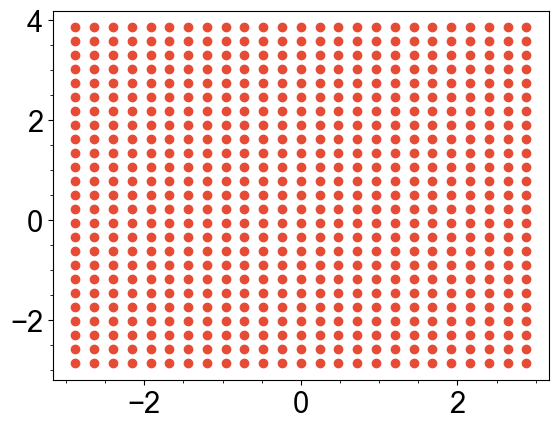

In [31]:
plt.scatter(mechanism_dfs["EC_prime"]["log_g"], mechanism_dfs["EC_prime"]["log_l"])

In [15]:
def plot_line(ax, p1, p2, num=200, **plot_kwargs):
    """
    Plot a straight line between two endpoints.
    
    Parameters:
        p1, p2: tuples (x, y)
        num: number of points
        plot_kwargs: passed to ax.plot()
    """
    x = np.linspace(p1[0], p2[0], num)
    y = np.linspace(p1[1], p2[1], num)
    ax.plot(x, y, **plot_kwargs)


def plot_bezier(ax, x_points, y_points, num=200, **plot_kwargs):
    """
    Plot a Bezier curve given control points.
    
    Parameters:
        x_points, y_points: arrays of control points
        num: number of samples
        plot_kwargs: passed to ax.plot()
    """
    t = np.linspace(0, 1, num)
    n = len(x_points) - 1

    x = np.zeros_like(t)
    y = np.zeros_like(t)

    for i in range(n + 1):
        B = comb(n, i) * (t**i) * ((1 - t)**(n - i))
        x += B * x_points[i]
        y += B * y_points[i]

    ax.plot(x, y, **plot_kwargs)

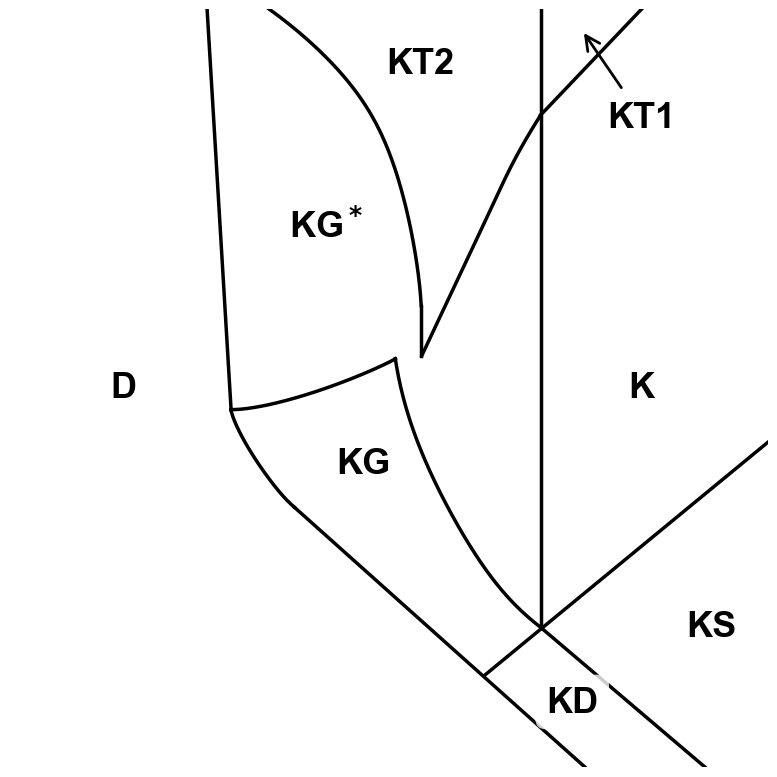

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from math import comb

fig, ax = plt.subplots(figsize=(8, 8))

xlim = (-3, 3)
ylim = (-3, 4)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
        
# Line segments
line_color = 'k'
lw = 2.5
alpha = 1
plot_line(ax, (-1.44, 4), (-1.25, 0.3), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (-0.75, -0.6), (1.55, -3.0), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (0.76, -2.15), (3, 0), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (1.2, -1.72), (1.2, 4), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (1.21, -1.72), (2.5, -3), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (1.2, 3.02), (2, 4), color=line_color, lw=lw, alpha=alpha)
plot_line(ax, (0.25, 0.80), (0.25, 1.26), color=line_color, lw=lw, alpha=alpha)
#plot_line(ax, (0.26, 0.80), (0.9, 2.35), color='k', lw=2)

# Bezier curves
x_control_points = np.array([-1.25, -1.25, -1.18, -1, -0.9, -0.75])
y_control_points = np.array([0.3, 0.26, 0, -0.25, -0.45, -0.6])
plot_bezier(ax, x_control_points, y_control_points, color=line_color, lw=lw, alpha=alpha)

x_control_points = np.array([0.255, 0.22, 0, -0.07, -0.35, -0.95])
y_control_points = np.array([1.26, 2, 2.85, 3, 3.5, 4])
plot_bezier(ax, x_control_points, y_control_points, color=line_color, lw=lw, alpha=alpha)

x_control_points = np.array([0.26, 0.5, 0.75, 0.9, 0.92, 1.2])
y_control_points = np.array([0.80, 1.4, 2, 2.38, 2.5, 3.02])
plot_bezier(ax, x_control_points, y_control_points, color=line_color, lw=lw, alpha=alpha)

x_control_points = np.array([-1.25, -1, -0.5, 0, 0.05])
y_control_points = np.array([0.3, 0.3, 0.45, 0.73, 0.77])
plot_bezier(ax, x_control_points, y_control_points, color=line_color, lw=lw, alpha=alpha)

x_control_points = np.array([0.05, 0.15, 0.4, 0.65, 0.8, 1.2])
y_control_points = np.array([0.77, 0, -0.5, -1, -1.35, -1.71])
plot_bezier(ax, x_control_points, y_control_points, color=line_color, lw=lw, alpha=alpha)


# Text labels
text_to_placement = {
    r"KG$^{\bf *}$": [-0.5, 2],
    "KT2": [0.25, 3.5],
    "K": [2, 0.5],
    "KG": [-0.2, -0.2],
    #"KT1": [1.53, 3.8],
    "KS": [2.55, -1.7],
    "D": [-2.1, 0.5],
    "KD": [1.45, -2.4],
}

# Then add the text with very high zorder
for label, (x, y) in text_to_placement.items():
    text = ax.text(
        x, y, label,
        ha='center',
        va='center',
        fontweight='bold',
        bbox=dict(facecolor='#FFFFFF', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8),
        alpha=1,
        size=26,
    )
    # Force the bbox to be drawn with the text
    text.set_clip_on(False)
    
# KT1 arrow + relocated label
ax.annotate(
    "KT1",
    xy=(1.53, 3.8),      # original point
    xytext=(2, 3),       # new label position
    textcoords='data',
    ha='center',
    va='center',
    fontsize=26,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        lw=2,
        color='k'
    ),
    bbox=dict(facecolor='#FFFFFF', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8),
)

# Remove all axes visuals
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

for spine in ax.spines.values():
    spine.set_visible(False)

# Remove all padding/margins
ax.set_position([0, 0, 1, 1])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.margins(0)

plt.tight_layout()

plt.savefig("zone_diagram_lines.png", dpi=300, transparent=True)
plt.show()

/var/folders/gx/s5zydc_s0r16y1p2w7xq83n00000gn/T/ipykernel_48338/1688800350.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


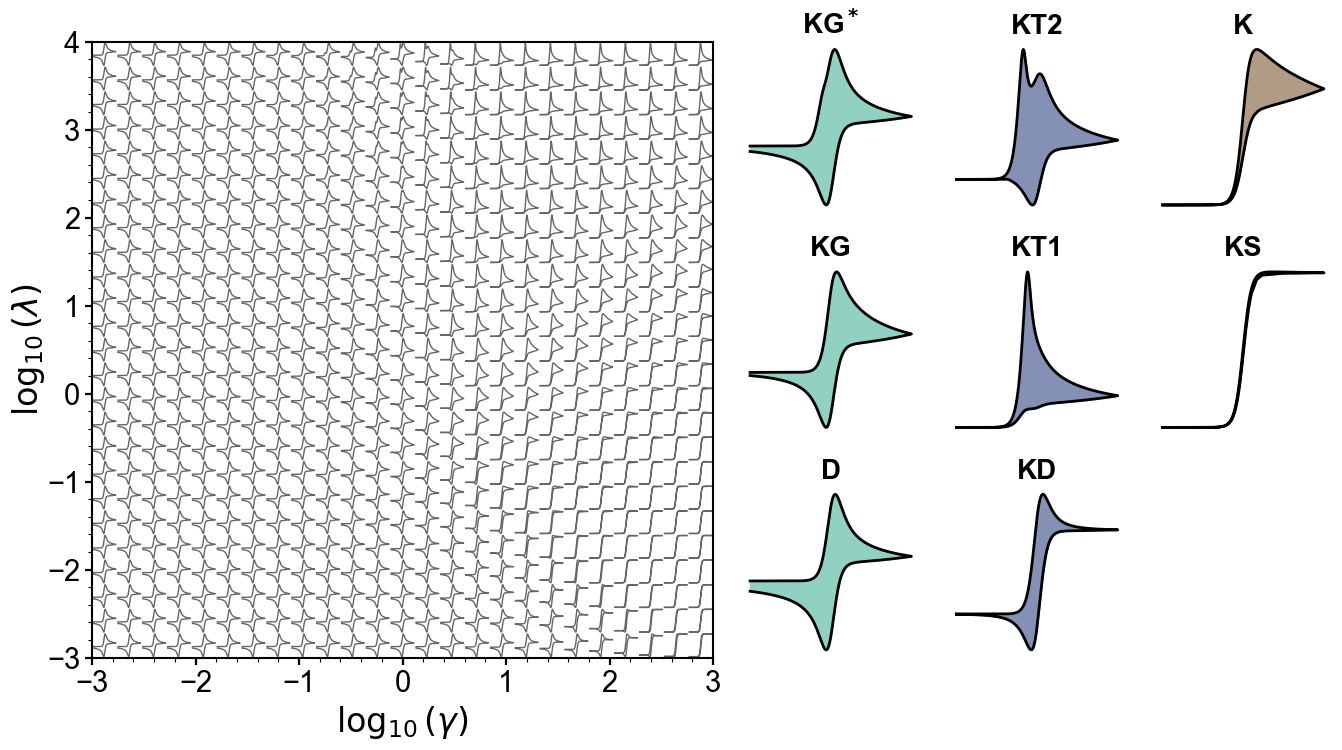

In [ ]:
# Get the EC dataframe
df = mechanism_dfs["EC_prime_new"]

fig = plt.figure(figsize=(16, 8))
gs = GridSpec(3, 4, figure=fig, width_ratios=[3.5, 1, 1, 1], wspace=0.1, hspace=0.3)

# Main plot
ax = fig.add_subplot(gs[:, 0])

xlim = (-3, 3)
ylim = (-3, 4)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xlabel(r"$\log_{10}(\gamma)$")
ax.set_ylabel(r"$\log_{10}(\lambda)$", labelpad=0)

# Increase border (spine) width
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='both', direction='out', top=False, right=False)
ax.tick_params(axis='both', which='major', length=5, width=1.6)
ax.tick_params(axis='both', which='minor', length=3, width=0.8)
ax.minorticks_on()

# Overlay CVs at each scatter point
for idx, row in df.iterrows():
    run_num = row['run_number']
    scan_rate = row['scan_rate']

    csv_scan_key = f"{scan_rate:.2e}".replace('.', 'p').replace('+', '')
    model_dir = f"new/EC_prime_new/model_{run_num:04d}"
    file_path = os.path.join(
        model_dir,
        f"model_{run_num:04d}_comsol_scan_scan_rate_{csv_scan_key}_V_s.csv"
    )

    if os.path.exists(file_path):
        cv_data = pd.read_csv(file_path)
        E = cv_data['E'].values
        i = cv_data['i'].values

        i = i / np.max(np.abs(i)) if np.max(np.abs(i)) > 0 else i

        inset_size = 0.1
        x0 = row['log_g']
        y0 = row['log_l']

        if not (xlim[0] <= x0 <= xlim[1] and ylim[0] <= y0 <= ylim[1]):
            continue

        ax_inset = inset_axes(
            ax,
            width=0.25,
            height=0.25,
            loc='center',
            bbox_to_anchor=(x0, y0),
            bbox_transform=ax.transData
        )
        
        ax_inset.set_facecolor('none')

        ax_inset.plot(E, i, color='k', lw=1, alpha=0.6)
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.axis('off')
        ax_inset.set_zorder(2) 


# Text labels
text_to_placement = {
    r"KG$^{\bf *}$": [-0.5, 2],
    "KT2": [0.25, 3.5],
    "K": [2, 0.5],
    "KG": [-0.2, -0.2],
    "KT1": [1.53, 3.8],
    "KS": [2.55, -1.7],
    "D": [-2.1, 0.5],
    "KD": [1.45, -2.4],
}

# ------------------------------------------------------------
# Create the 6 CV subplots
# ------------------------------------------------------------
labels = list(text_to_placement.keys())

for idx, label in enumerate(labels):

    r = idx // 3
    c = idx % 3

    ax_cv = fig.add_subplot(gs[r, c+1])

    x_label, y_label = text_to_placement[label]

    # Find closest dataframe point
    distances = np.sqrt((df['log_g'] - x_label)**2 + (df['log_l'] - y_label)**2)
    closest_idx = distances.idxmin()
    row = df.loc[closest_idx]

    run_num = row['run_number']
    scan_rate = row['scan_rate']

    csv_scan_key = f"{scan_rate:.2e}".replace('.', 'p').replace('+', '')
    model_dir = f"new/EC_prime_new/model_{run_num:04d}"
    file_path = os.path.join(
        model_dir,
        f"model_{run_num:04d}_comsol_scan_scan_rate_{csv_scan_key}_V_s.csv"
    )

    if os.path.exists(file_path):

        cv_data = pd.read_csv(file_path)
        E = cv_data['E'].values
        i = cv_data['i'].values

        # Normalize
        i = i / np.max(np.abs(i)) if np.max(np.abs(i)) > 0 else i

        # --- Split forward/reverse at peak (~E = 1) ---
        peak_idx = np.argmin(np.abs(E - 1))
        E_fwd, i_fwd = E[:peak_idx+1], i[:peak_idx+1]
        E_rev, i_rev = E[peak_idx:], i[peak_idx:]

        # --- E points ---
        E_combined = np.union1d(E_fwd, E_rev)

        # --- Interpolation ---
        fwd_interp = interp1d(E_fwd, i_fwd, kind='linear',
                              bounds_error=False, fill_value="extrapolate")
        rev_interp = interp1d(E_rev, i_rev, kind='linear',
                              bounds_error=False, fill_value="extrapolate")

        i_fwd_new = fwd_interp(E_combined)
        i_rev_new = rev_interp(E_combined)

        # --- Column-based colors ---
        col_colors = ['#91D1C2', '#8491B4', '#B09C85']
        color = col_colors[c]

        # --- Fill between curves ---
        ax_cv.fill_between(E_combined, i_fwd_new, i_rev_new,
                           color=color, alpha=1)

        # Outline CV
        ax_cv.plot(E, i, color='k', lw=2)
        
        #ax_cv.fill_between(E, i, color='red', alpha=0.5)

    ax_cv.set_title(label, fontsize=20, fontweight='bold')

#     ax_cv.set_xlabel(r'$E$ (V)', fontsize=15)
#     ax_cv.set_ylabel(r'$i$ (A)', fontsize=15)

#     ax_cv.minorticks_on()

    # Remove top/right spines
    ax_cv.spines['top'].set_visible(False)
    ax_cv.spines['right'].set_visible(False)
    
    # Hide spines
    ax_cv.spines[["left", "right", "top", "bottom"]].set_visible(False)

    # Remove ticks and labels
    ax_cv.set_xticks([])
    ax_cv.set_yticks([])

plt.tight_layout()

plt.savefig("zone_diagram_ec_prime_newer.png", dpi=300)
plt.show()